# Benchmark - OpenAI's GPT-5.6 Terra

**Date:** 13-14 Aug 2026

**Evaluation:** Tasks 01-07

**Hardware:** Cloud

In [1]:
import textwrap

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from matplotlib.patches import Patch

from benchmark_lib import (
  DATA_DIR,
  RUNS_PER_BATCH,
  SERIES,
  add_token_counts,
  compare_skills,
  latest_batches,
  load_runs,
  metric_table,
  plot_benchmark,
  plot_skill_summary,
  save_runs,
)

HARDWARE = "cloud"
MODEL_LABEL = "GPT-5.6 Terra"


In [2]:
MODEL_NAME = "gpt-5.6-terra"
benchmark_dir = DATA_DIR / "openai" / MODEL_NAME

if (not benchmark_dir.exists()):
  all_runs = load_runs(model=MODEL_NAME, hardware=HARDWARE)
  df = add_token_counts(latest_batches(all_runs))
  save_runs(df, benchmark_dir, redact=("openai",))


In [3]:
benchmark = pd.read_csv(benchmark_dir / "benchmark.csv")
benchmark["start_time"] = pd.to_datetime(benchmark["start_time"])
benchmark.head()


,task,run,start_time,skills,score,points,total,passed,structure_match,duration_seconds,...,model,harness,model_server,hardware,fields,input_tokens,output_tokens,cache_read_tokens,cache_write_tokens,total_tokens
0,01-data-loading,20260813_212141_n1,2026-08-13 21:21:52.428171,False,1.0,5,5,True,True,54,...,gpt-5.6-terra,pi,openai,cloud,"{'n_cells': {'expected': 20857, 'actual': 2085...",24,2657,22422,5664,30767
1,01-data-loading,20260813_212235_n2,2026-08-13 21:22:46.828555,False,1.0,5,5,True,True,104,...,gpt-5.6-terra,pi,openai,cloud,"{'n_cells': {'expected': 20857, 'actual': 2085...",57,4020,100758,9194,114029
2,01-data-loading,20260813_212246_n3,2026-08-13 21:22:57.671727,False,1.0,5,5,True,True,114,...,gpt-5.6-terra,pi,openai,cloud,"{'n_cells': {'expected': 20857, 'actual': 2085...",63,4319,135181,12856,152419
3,01-data-loading,20260813_212431_n4,2026-08-13 21:24:42.312424,False,1.0,5,5,True,True,107,...,gpt-5.6-terra,pi,openai,cloud,"{'n_cells': {'expected': 20857, 'actual': 2085...",54,3712,95165,9754,108685
4,01-data-loading,20260813_212452_n5,2026-08-13 21:25:03.250831,False,1.0,5,5,True,True,93,...,gpt-5.6-terra,pi,openai,cloud,"{'n_cells': {'expected': 20857, 'actual': 2085...",45,4009,68073,8904,81031


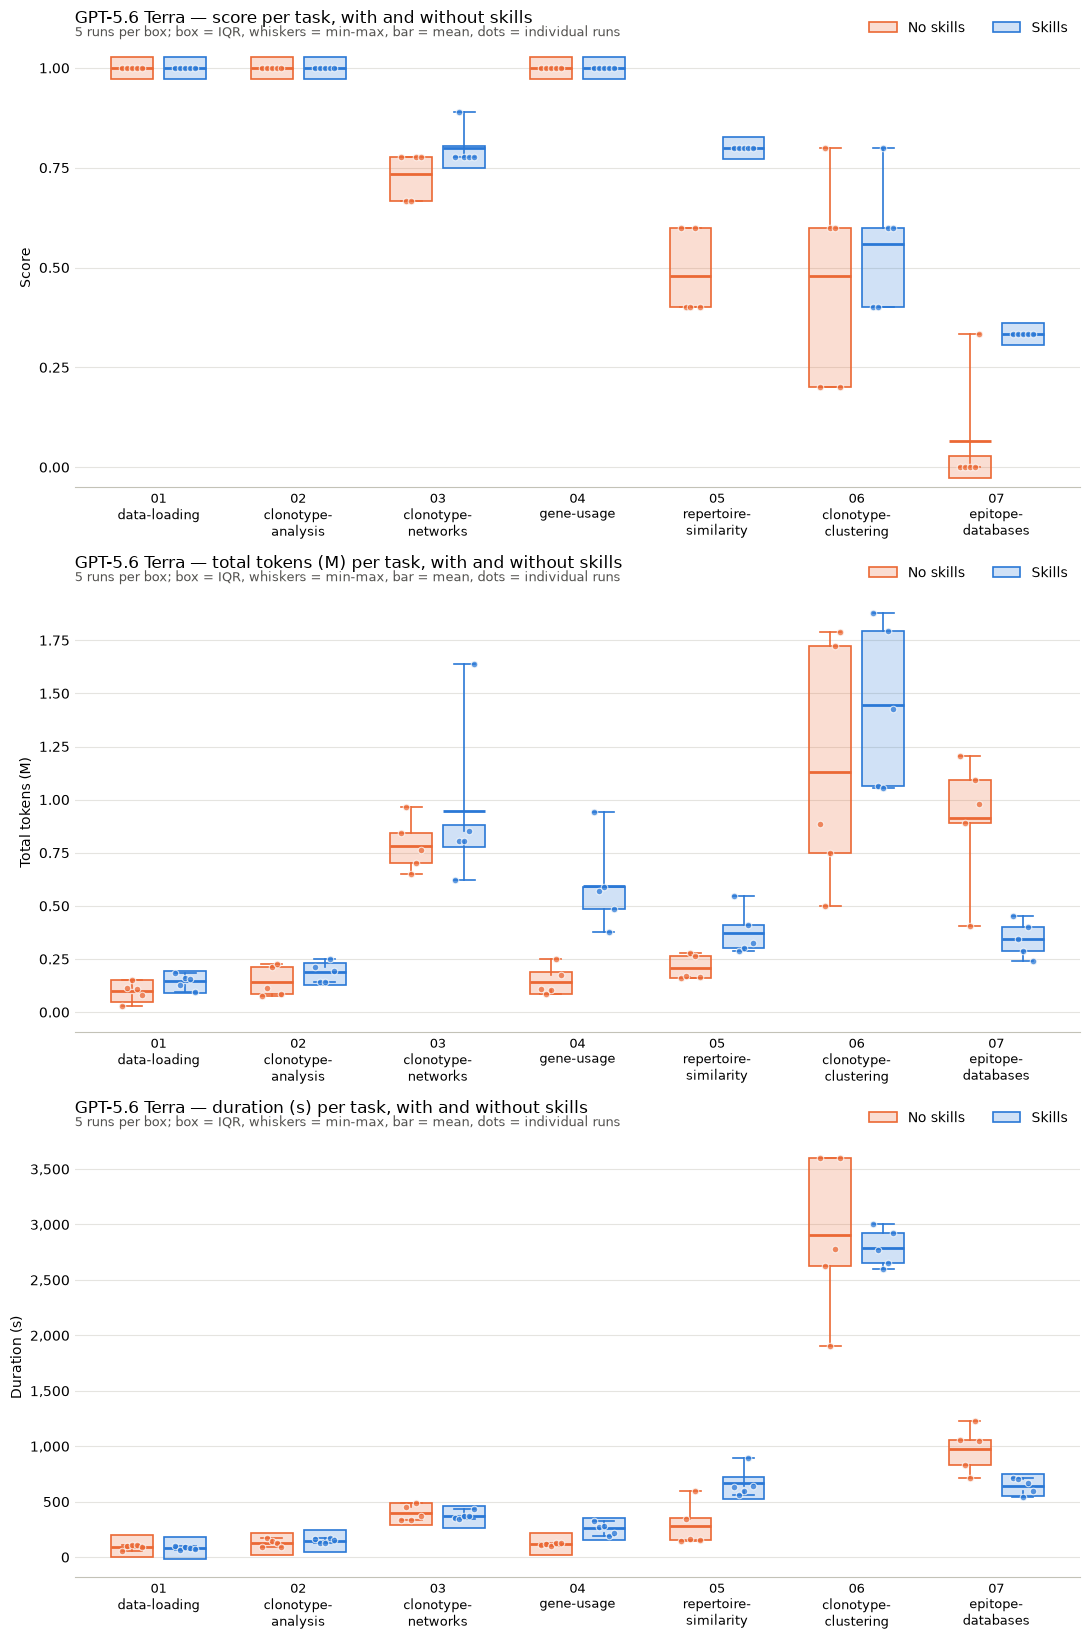

In [4]:
fig, axs = plt.subplots(nrows=3, ncols=1, figsize=(11, 5.5 * 3))
plot_benchmark(benchmark, column="score", model_label=MODEL_LABEL, ax=axs[0])
plot_benchmark(benchmark, column="total_tokens", model_label=MODEL_LABEL, ax=axs[1])
plot_benchmark(benchmark, column="duration_seconds", model_label=MODEL_LABEL, ax=axs[2])
fig.tight_layout()
plt.show()


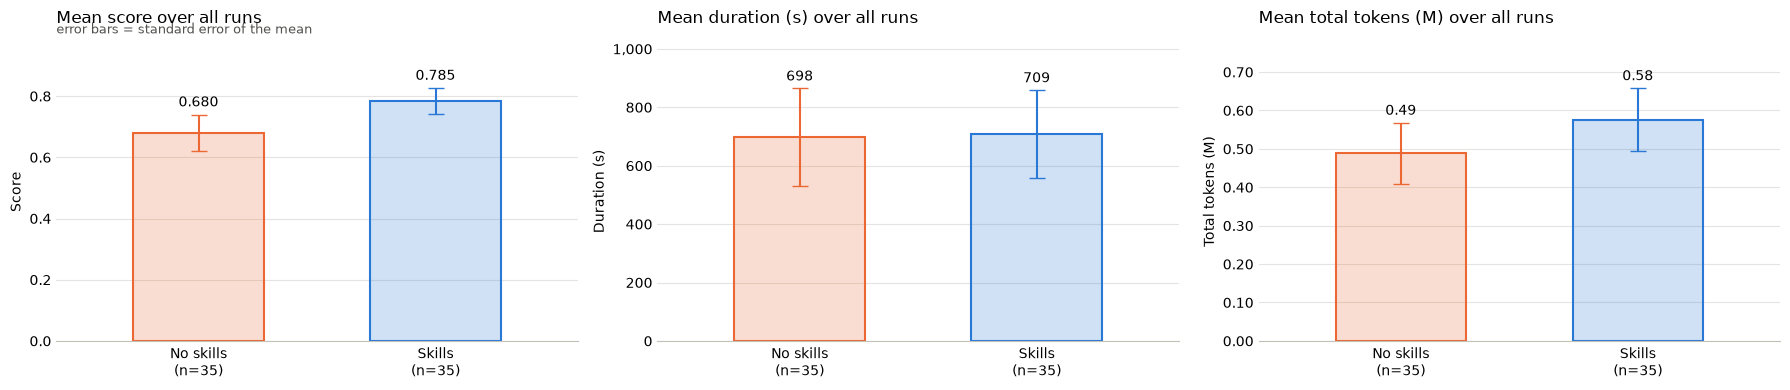

In [5]:
fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(6 * 3, 4))
plot_skill_summary(benchmark, axs=axs)
fig.tight_layout()
plt.show()


In [6]:
significance = compare_skills(benchmark)


In [7]:
metric_table(significance, "score")


,scope,test,n,mean_no_skills,mean_skills,diff,p_value,p_fdr,significant_fdr
0,all tasks (pooled),Mann-Whitney U,35 vs 35,0.680000,0.784762,0.104762,0.326609,NaN,False
1,01-data-loading,Mann-Whitney U,5 vs 5,1.000000,1.000000,0.000000,1.000000,1.000000,False
2,02-clonotype-analysis,Mann-Whitney U,5 vs 5,1.000000,1.000000,0.000000,1.000000,1.000000,False
3,03-clonotype-networks,Mann-Whitney U,5 vs 5,0.733333,0.800000,0.066667,0.121335,0.283116,False
4,04-gene-usage,Mann-Whitney U,5 vs 5,1.000000,1.000000,0.000000,1.000000,1.000000,False
5,05-repertoire-similarity,Mann-Whitney U,5 vs 5,0.480000,0.800000,0.320000,0.006502,0.045512,True
6,06-clonotype-clustering,Mann-Whitney U,5 vs 5,0.480000,0.560000,0.080000,0.744073,1.000000,False
7,07-epitope-databases,Mann-Whitney U,5 vs 5,0.066667,0.333333,0.266667,0.019964,0.069876,False
8,all tasks (paired by task),Wilcoxon signed-rank,7 tasks,0.680000,0.784762,0.104762,0.125000,NaN,False


In [8]:
metric_table(significance, "duration_seconds")


,scope,test,n,mean_no_skills,mean_skills,diff,p_value,p_fdr,significant_fdr
0,all tasks (pooled),Mann-Whitney U,35 vs 35,698.371429,709.4,11.028571,0.362636,NaN,False
1,01-data-loading,Mann-Whitney U,5 vs 5,94.400000,82.0,-12.400000,0.222222,0.388889,False
2,02-clonotype-analysis,Mann-Whitney U,5 vs 5,125.600000,149.6,24.000000,0.345742,0.484039,False
3,03-clonotype-networks,Mann-Whitney U,5 vs 5,395.400000,374.8,-20.600000,0.916563,0.916563,False
4,04-gene-usage,Mann-Whitney U,5 vs 5,115.600000,259.4,143.800000,0.007937,0.037037,True
5,05-repertoire-similarity,Mann-Whitney U,5 vs 5,282.600000,665.2,382.600000,0.015873,0.037037,True
6,06-clonotype-clustering,Mann-Whitney U,5 vs 5,2901.000000,2790.2,-110.800000,0.841270,0.916563,False
7,07-epitope-databases,Mann-Whitney U,5 vs 5,974.000000,644.6,-329.400000,0.015873,0.037037,True
8,all tasks (paired by task),Wilcoxon signed-rank,7 tasks,698.371429,709.4,11.028571,0.937500,NaN,False


In [9]:
metric_table(significance, "total_tokens")


,scope,test,n,mean_no_skills,mean_skills,diff,p_value,p_fdr,significant_fdr
0,all tasks (pooled),Mann-Whitney U,35 vs 35,4.884286e+05,5.760209e+05,87592.257143,0.151851,NaN,False
1,01-data-loading,Mann-Whitney U,5 vs 5,9.738620e+04,1.453786e+05,47992.400000,0.095238,0.166667,False
2,02-clonotype-analysis,Mann-Whitney U,5 vs 5,1.423418e+05,1.884442e+05,46102.400000,0.420635,0.490741,False
3,03-clonotype-networks,Mann-Whitney U,5 vs 5,7.838338e+05,9.442330e+05,160399.200000,0.690476,0.690476,False
4,04-gene-usage,Mann-Whitney U,5 vs 5,1.440776e+05,5.920184e+05,447940.800000,0.007937,0.027778,True
5,05-repertoire-similarity,Mann-Whitney U,5 vs 5,2.080162e+05,3.736152e+05,165599.000000,0.007937,0.027778,True
6,06-clonotype-clustering,Mann-Whitney U,5 vs 5,1.128845e+06,1.443615e+06,314770.400000,0.222222,0.311111,False
7,07-epitope-databases,Mann-Whitney U,5 vs 5,9.145000e+05,3.448416e+05,-569658.400000,0.015873,0.037037,True
8,all tasks (paired by task),Wilcoxon signed-rank,7 tasks,4.884286e+05,5.760209e+05,87592.257143,0.296875,NaN,False


In [10]:
PRICES_USD_PER_MTOK = {  # GPT-5.6 Terra, USD per million tokens
  "input_tokens": 2.00,
  "cache_write_tokens": 2.50,  # 5-minute TTL; no run used the 1h cache ($10)
  "cache_read_tokens": 0.20,
  "output_tokens": 12.00,
}

def add_cost(runs: pd.DataFrame) -> pd.DataFrame:
  cost = sum(runs[column] * price for column, price in PRICES_USD_PER_MTOK.items()) / 1e6
  return runs.assign(cost_usd=cost)

priced = add_cost(benchmark)


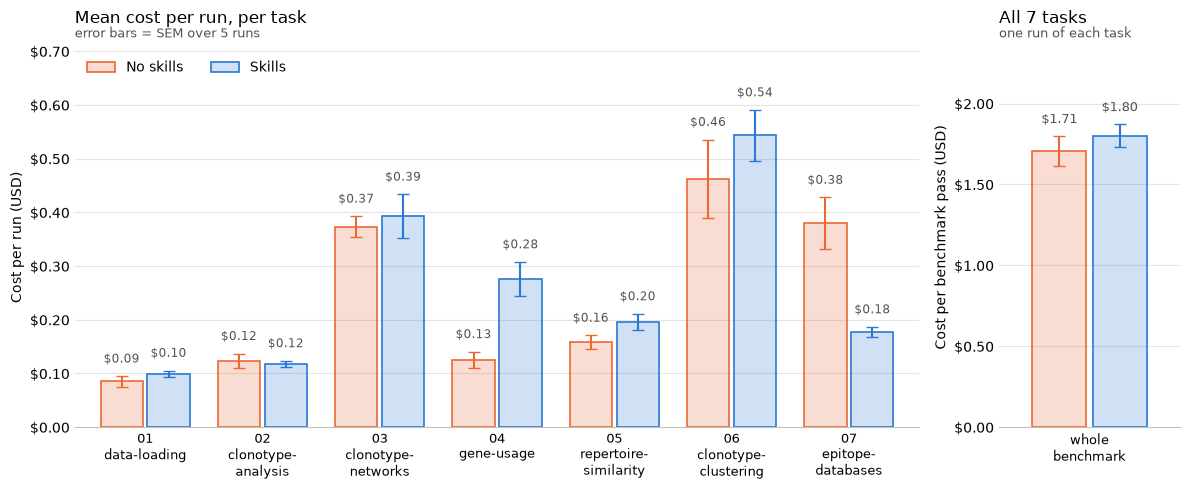

In [11]:
def style_cost_axis(ax):
  ax.grid(axis="y", color="#e5e4e0", linewidth=0.8)
  ax.set_axisbelow(True)
  for side in ("top", "right", "left"):
    ax.spines[side].set_visible(False)
  ax.spines["bottom"].set_color("#c3c2b7")
  ax.tick_params(length=0)
  ax.yaxis.set_major_formatter(lambda v, _: f"\\${v:,.2f}")  # \$ is not mathtext

def plot_cost(runs: pd.DataFrame, axs=None):
  tasks = sorted(runs["task"].unique())
  if axs is None:
    _, axs = plt.subplots(1, 2, figsize=(12, 5), gridspec_kw={"width_ratios": [7, 1.5]})
  task_ax, benchmark_ax = axs
  pass_costs, pass_errors = [], []

  for skills, (color, _) in SERIES.items():
    arm = runs[runs["skills"] == skills]
    stats = arm.groupby("task")["cost_usd"].agg(["mean", "sem"]).reindex(tasks)
    xs = [i + (0.2 if skills else -0.2) for i in range(len(tasks))]
    task_ax.bar(
      xs, stats["mean"], yerr=stats["sem"], width=0.36, color=color + "38",
      edgecolor=color, linewidth=1.2, ecolor=color, capsize=4, zorder=2,
    )
    for x, mean, error in zip(xs, stats["mean"], stats["sem"]):
      task_ax.text(
        x, mean + error + 0.02, f"\\${mean:.2f}",
        ha="center", va="bottom", fontsize=8.5, color="#52514e",
      )

    # a benchmark pass is one run of each task, so sum the per-task means;
    # tasks are independent runs, so their standard errors add in quadrature
    pass_cost = stats["mean"].sum()
    pass_error = np.sqrt((stats["sem"] ** 2).sum())
    pass_costs.append(pass_cost)
    pass_errors.append(pass_error)
    x = 0.2 if skills else -0.2
    benchmark_ax.bar(
      x, pass_cost, yerr=pass_error, width=0.36, color=color + "38",
      edgecolor=color, linewidth=1.2, ecolor=color, capsize=4, zorder=2,
    )
    benchmark_ax.text(
      x, pass_cost + pass_error + 0.06, f"\\${pass_cost:.2f}",
      ha="center", va="bottom", fontsize=9, color="#52514e",
    )

  task_ax.set_xticks(range(len(tasks)))
  task_ax.set_xticklabels(
    [f'{t.split("-")[0]}\n' + textwrap.fill(t.split("-", 1)[1], 12) for t in tasks], fontsize=9
  )
  task_ax.set_xlim(-0.6, len(tasks) - 0.4)
  task_ax.set_ylim(0, runs.groupby(["task", "skills"])["cost_usd"].mean().max() * 1.3)
  task_ax.set_ylabel("Cost per run (USD)")
  task_ax.set_title("Mean cost per run, per task", loc="left", pad=18)
  task_ax.text(
    0, 1.02, f"error bars = SEM over {RUNS_PER_BATCH} runs", transform=task_ax.transAxes,
    ha="left", va="bottom", fontsize=9, color="#52514e",
  )
  task_ax.legend(
    handles=[
      Patch(facecolor=color + "38", edgecolor=color, linewidth=1.2, label=label)
      for color, label in SERIES.values()
    ],
    frameon=False, loc="upper left", ncol=2,
  )
  style_cost_axis(task_ax)

  benchmark_ax.set_xticks([0])
  benchmark_ax.set_xticklabels(["whole\nbenchmark"], fontsize=9)
  benchmark_ax.set_xlim(-0.6, 0.6)
  benchmark_ax.set_ylim(0, max(c + e for c, e in zip(pass_costs, pass_errors)) * 1.25)
  benchmark_ax.set_ylabel("Cost per benchmark pass (USD)")
  benchmark_ax.set_title(f"All {len(tasks)} tasks", loc="left", pad=18)
  benchmark_ax.text(
    0, 1.02, "one run of each task", transform=benchmark_ax.transAxes,
    ha="left", va="bottom", fontsize=9, color="#52514e",
  )
  style_cost_axis(benchmark_ax)
  return axs

fig, axs = plt.subplots(1, 2, figsize=(12, 5), gridspec_kw={"width_ratios": [7, 1.5]})
plot_cost(priced, axs=axs)
fig.tight_layout()
plt.show()
